In [1]:
import os

SIGMA_ENV = "/home/lemgui01/.miniconda3/envs/sigma_compare"

os.environ["R_HOME"] = f"{SIGMA_ENV}/lib/R"
os.environ["R_DEFAULT_PACKAGES"] = "datasets,utils,grDevices,graphics,stats,methods"
os.environ["PATH"] = f"{SIGMA_ENV}/bin:" + os.environ.get("PATH", "")
os.environ["LD_LIBRARY_PATH"] = f"{SIGMA_ENV}/lib/R/lib:" + os.environ.get("LD_LIBRARY_PATH", "")
os.environ["LC_ALL"] = "C"
os.environ["LANG"] = "C"

import numpy as np
import scipy.sparse as sp
import scipy.io as sio
import scanpy as sc
import pandas as pd
from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import re

import rpy2.robjects as ro
from rpy2.robjects import numpy2ri
from rpy2.robjects.conversion import localconverter
from rpy2.robjects.packages import importr

print("libPaths utilisés par rpy2:", list(ro.r('.libPaths()')))

r_base   = importr("base")
r_matrix = importr("Matrix")
r_seurat = importr("Seurat")
r_cellid = importr("CelliD")

print("✅ rpy2 + packages R chargés avec succès.")

libPaths utilisés par rpy2: ['/home/lemgui01/R/x86_64-conda-linux-gnu-library/4.5', '/home/lemgui01/.miniconda3/envs/sigma_compare/lib/R/library']
✅ rpy2 + packages R chargés avec succès.


In [2]:
# --- Paths ---
PATH_FULL  = "/mnt/projects_tn03/AD_EB_singlecell/archive/Dominguez_science_science-abl5197.h5ad"
PATH_SIGMA = "/mnt/projects_tn03/AD_EB_singlecell/articleSIGMA-results/results_dominguez/merge.h5ad"

# --- SIGMA threshold ---
SIGMA_THRESHOLD = 0.95

# --- CellID gene sets (config/StudyCaseDominguez.conf: [Target] / [LowIn]) ---
TARGET_GENES = ["GZMK", "GZMB", "NKG7", "PRF1", "CX3CR1", "IL7R", "CD44"]

EXCLUSION_GENES = ["CCR7", "SELL", "TCF7", "LEF1", "CXCR5", "CD27", "FOXP3",
                    "TRDC", "TRGC1", "TRGC2"]

# --- CellID threshold ---
CELLID_HGT_THRESHOLD_PERCENTILE = 99

# --- Validation marker panels ---
T_CELL_MARKERS = ["CD3E", "TRAC", "CD8A", "CD8B"]
NK_MARKERS = ["NCAM1", "KLRD1", "FCGR3A", "GNLY"]
NON_CYTOTOXIC  = ["CD4", "FOXP3", "TCF7", "SELL"]

# --- Plot colors ---
BLUE = "#1f77b4"    # SIGMA+
PURPLE = "#9467bd"  # CellID+
rng = np.random.default_rng(42)

# --- Perf ---
MIN_CELLS_PER_GENE = 10   # filtre pré-MCA (comptage minimal)
# RunMCA (CelliD) convertit la matrice en dense via Armadillo compilé sans
# ARMA_64BIT_WORD : au-delà de ~2^31 éléments (genes x cells), ça plante avec
# "Mat::init(): requested size is too large". Avec 329 762 cellules, il faut
# rester sous ~6500 gènes ; on prend une marge de sécurité.
MAX_GENES_MCA = 5000
N_WORKERS_HGT = 20          # ajuster selon les cores dispo sur vls144
TMP_DIR = "/tmp/cellid_transfer"
os.makedirs(TMP_DIR, exist_ok=True)

In [3]:
adata_full  = sc.read_h5ad(PATH_FULL)
adata_sigma = sc.read_h5ad(PATH_SIGMA)

print(f"adata_full  : {adata_full.shape[0]:,} cells x {adata_full.shape[1]:,} genes")
print(f"adata_sigma : {adata_sigma.shape[0]:,} cells x {adata_sigma.shape[1]:,} genes")

adata_full  : 329,762 cells x 36,601 genes
adata_sigma : 41,214 cells x 36,601 genes


In [4]:
adata_sigma_thresh = adata_sigma[adata_sigma.obs["score"] >= SIGMA_THRESHOLD].copy()

adata_sigma_thresh.obs_names = adata_sigma_thresh.obs_names.str.replace(
    r"-Dominguez_.*?_data$", "", regex=True
)

adata_full.obs["sigma_positive"] = adata_full.obs_names.isin(set(adata_sigma_thresh.obs_names))

mask_sigma = adata_full.obs["sigma_positive"]
print(f"SIGMA+ : {mask_sigma.sum():,}")

SIGMA+ : 2,698


In [5]:
# --- Sous-échantillonnage pour test rapide du pipeline (shim GetAssayData + RunMCA + RunCellHGT) ---
# Mettre SUBSAMPLE_N = None pour désactiver et lancer sur les 329k cellules complètes.
SUBSAMPLE_N = None

if SUBSAMPLE_N is not None and adata_full.shape[0] > SUBSAMPLE_N:
    idx = rng.choice(adata_full.shape[0], size=SUBSAMPLE_N, replace=False)
    idx.sort()
    adata_full = adata_full[idx].copy()
    print(f"Sous-échantillonné à {adata_full.shape[0]:,} cellules pour test")


In [6]:
# --- Transfert vers R via disque (mtx) plutôt que via rpy2 objet-par-objet ---
# Nettement plus rapide pour de gros comptages (évite l'overhead IntVector/FloatVector de rpy2)

counts = adata_full.layers["counts"] if "counts" in adata_full.layers else adata_full.X
counts_gxc = sp.csc_matrix(counts).T  # genes x cells, comme attendu par Seurat

mtx_path   = os.path.join(TMP_DIR, "counts_gxc.mtx")
genes_path = os.path.join(TMP_DIR, "genes.txt")
cells_path = os.path.join(TMP_DIR, "cells.txt")

sio.mmwrite(mtx_path, counts_gxc)
with open(genes_path, "w") as f:
    f.write("\n".join(adata_full.var_names.tolist()))
with open(cells_path, "w") as f:
    f.write("\n".join(adata_full.obs_names.tolist()))

print(f"Écrit sur disque : {counts_gxc.shape[0]:,} genes x {counts_gxc.shape[1]:,} cells")

ro.globalenv["mtx_path"]        = mtx_path
ro.globalenv["genes_path"]      = genes_path
ro.globalenv["cells_path"]      = cells_path
ro.globalenv["target_genes"]    = ro.StrVector(TARGET_GENES)
ro.globalenv["exclusion_genes"] = ro.StrVector(EXCLUSION_GENES)
ro.globalenv["min_cells_gene"]  = MIN_CELLS_PER_GENE
ro.globalenv["max_genes_mca"]   = MAX_GENES_MCA
ro.globalenv["n_workers_hgt"]   = N_WORKERS_HGT

Écrit sur disque : 36,601 genes x 329,762 cells


In [7]:
ro.r("""
options(Seurat.object.assay.version = "v3")

# --- Lecture depuis disque (rapide, évite la conversion rpy2 élément-par-élément) ---
counts_mat <- Matrix::readMM(mtx_path)
counts_mat <- as(counts_mat, "CsparseMatrix")
dimnames(counts_mat) <- list(
  readLines(genes_path),
  readLines(cells_path)
)
cat(sprintf("Chargé dans R : %d genes x %d cells\\n", nrow(counts_mat), ncol(counts_mat)))

seurat_obj <- Seurat::CreateSeuratObject(counts = counts_mat)

# --- Filtrage des gènes avant MCA ---
# 1) filtre de comptage minimal (accélère MCA quasi-linéairement)
detected <- Matrix::rowSums(seurat_obj[["RNA"]]$counts > 0) >= min_cells_gene
cat(sprintf("Gènes conservés après filtre comptage : %d / %d\\n", sum(detected), length(detected)))
seurat_obj <- subset(seurat_obj, features = rownames(seurat_obj)[detected])

# 2) plafond dur : RunMCA (CelliD) convertit la matrice en dense via Armadillo
# compilé sans ARMA_64BIT_WORD. Au-delà de ~2^31 éléments (genes x cells), ça
# plante avec "Mat::init(): requested size is too large". On garde les gènes
# les plus détectés jusqu'à max_genes_mca, en s'assurant que les gènes
# cibles/exclusion (indispensables pour RunCellHGT) sont toujours inclus.
if (nrow(seurat_obj) > max_genes_mca) {
  gene_counts <- Matrix::rowSums(seurat_obj[["RNA"]]$counts)
  priority_genes <- intersect(c(target_genes, exclusion_genes), rownames(seurat_obj))
  other_genes <- setdiff(rownames(seurat_obj), priority_genes)
  n_other <- max_genes_mca - length(priority_genes)
  top_other <- names(sort(gene_counts[other_genes], decreasing = TRUE))[seq_len(n_other)]
  keep_genes <- c(priority_genes, top_other)
  seurat_obj <- subset(seurat_obj, features = keep_genes)
  cat(sprintf("Gènes plafonnés à %d pour rester sous la limite Armadillo 32-bit (%d cells x %d genes = %.2e éléments)\\n",
              nrow(seurat_obj), ncol(seurat_obj), nrow(seurat_obj), as.double(ncol(seurat_obj)) * nrow(seurat_obj)))
}

# Sécurité : vérifier que les gènes cibles/exclusion sont bien dans les gènes filtrés
missing_target <- setdiff(target_genes, rownames(seurat_obj))
missing_exclusion <- setdiff(exclusion_genes, rownames(seurat_obj))
if (length(missing_target) > 0) cat("⚠️ Gènes cibles absents après filtrage:", missing_target, "\\n")
if (length(missing_exclusion) > 0) cat("⚠️ Gènes exclusion absents après filtrage:", missing_exclusion, "\\n")

seurat_obj <- Seurat::NormalizeData(seurat_obj)

# --- Compat shim : CelliD 1.18.0 appelle GetAssayData(slot=...), argument devenu
# defunct dans SeuratObject >= 5.0 (remplacé par layer=). RunMCA.Seurat résout
# GetAssayData via l'environnement d'imports du package CelliD (pas un binding direct
# du namespace), donc on patche cet environnement plutôt que d'utiliser assignInNamespace.
shimmed_GetAssayData <- function(object, slot = NULL, layer = NULL, ...) {
  if (!is.null(slot) && is.null(layer)) layer <- slot
  SeuratObject::GetAssayData(object, layer = layer, ...)
}
celliD_imports <- parent.env(asNamespace("CelliD"))
unlockBinding("GetAssayData", celliD_imports)
assign("GetAssayData", shimmed_GetAssayData, envir = celliD_imports)
lockBinding("GetAssayData", celliD_imports)

seurat_obj <- CelliD::RunMCA(seurat_obj, nmcs = 50)

gene_sets <- list(target = target_genes, exclusion = exclusion_genes)

# --- RunCellHGT séquentiel ---
# La CelliD 1.18.0 installée n'expose pas de paramètre BPPARAM (RunCellHGT.Seurat est
# purement séquentiel dans cette version). Une parallélisation manuelle via mclapply()
# a été tentée (à la fois via rpy2 et via Rscript en subprocess indépendant) mais
# provoque systématiquement un blocage : OpenBLAS (libopenblasp, utilisé par
# RcppArmadillo dans CelliD.so) initialise un threadpool interne qui n'est pas
# fork-safe — après fork(), les workers restent bloqués en attente sur des futex
# du threadpool OpenBLAS hérité du parent. Confirmé indépendant de rpy2 (reproduit
# aussi en Rscript pur), indépendant du nombre de coeurs (persiste même avec
# taskset limité à 2 CPUs) et indépendant des variables OMP_NUM_THREADS/
# OPENBLAS_NUM_THREADS. On reste donc en séquentiel ici ; c'est fiable même si
# plus lent (RunMCA seul a pris ~9 min sur les 329k cellules complètes).
# minSize doit être <= à la taille du plus petit pathway (target_genes = 7 gènes),
# sinon RunCellHGT filtre silencieusement ce pathway (défaut minSize = 10) et la
# matrice hgt retournée n'a plus de ligne "target".
min_pathway_size <- min(length(target_genes), length(exclusion_genes))

hgt <- CelliD::RunCellHGT(
    seurat_obj, pathways = gene_sets, dims = 1:50,
    n.features = length(target_genes),
    minSize = min_pathway_size
)

cat("Pathways dans hgt :", paste(rownames(hgt), collapse = ", "), "\\n")

target_scores    <- as.numeric(hgt["target", ])
exclusion_scores <- as.numeric(hgt["exclusion", ])

cat("✅ RunCellHGT terminé.\\n")
""")

Charg<U+00E9> dans R : 36601 genes x 329762 cells
G<U+00E8>nes conserv<U+00E9>s apr<U+00E8>s filtre comptage : 28025 / 36601
G<U+00E8>nes plafonn<U+00E9>s <U+00E0> 5000 pour rester sous la limite Armadillo 32-bit (329762 cells x 5000 genes = 1.65e+09 <U+00E9>l<U+00E9>ments)


R callback write-console: Performing log-normalization
  
R callback write-console: 0%   10   20   30   40   50   60   70   80   90   100%
  
R callback write-console: [----|----|----|----|----|----|----|----|----|----|
  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *

425.926 sec elapsed


R callback write-console: Computing SVD
  


384.75 sec elapsed


...

R callback write-console: 2 pathways kept for hypergeometric test out of 2, 0 filtered as less than 7 features was present in the data
  
R callback write-console: 
calculating features overlap

  


  |                                                  | 0 % ~calculating   |+++++++++++++++++++++++++                         | 50% ~00s           |++++++++++++++++++++++++++++++++++++++++++++++++++| 100% elapsed=00s  


R callback write-console: performing hypergeometric test

  


  |                                                  | 0 % ~calculating   |+++++++++++++++++++++++++                         | 50% ~00s           |++++++++++++++++++++++++++++++++++++++++++++++++++| 100% elapsed=00s  
Pathways dans hgt : target, exclusion 
<U+2705> RunCellHGT termin<U+00E9>.


R callback write-console: In addition:   
R callback write-console: Warning messages:
  
R callback write-console: 1:   
R callback write-console: In readLines(genes_path) :  
R callback write-console: 
   
R callback write-console:  incomplete final line found on '/tmp/cellid_transfer/genes.txt'
  
R callback write-console: 2:   
R callback write-console: In readLines(cells_path) :  
R callback write-console: 
   
R callback write-console:  incomplete final line found on '/tmp/cellid_transfer/cells.txt'
  
R callback write-console: 3:   
R callback write-console: In asMethod(object) :  
R callback write-console: 
   
R callback write-console:  sparse->dense coercion: allocating vector of size 12.3 GiB
  


In [13]:
# Récupération des scores dans Python pour la suite de l'analyse
with localconverter(ro.default_converter + numpy2ri.converter):
    target_scores    = np.array(ro.globalenv["target_scores"])
    exclusion_scores = np.array(ro.globalenv["exclusion_scores"])

print(f"target_scores    : {target_scores.shape}")
print(f"exclusion_scores : {exclusion_scores.shape}")

# `hgt` columns follow the column order of counts_mat, i.e. adata_full.obs_names.
target_thresh    = np.percentile(target_scores, CELLID_HGT_THRESHOLD_PERCENTILE)
exclusion_thresh = np.percentile(exclusion_scores, CELLID_HGT_THRESHOLD_PERCENTILE)

adata_full.obs["cellid_hgt_score_target"]    = target_scores
adata_full.obs["cellid_hgt_score_exclusion"] = exclusion_scores
adata_full.obs["cellid_positive"] = (
    (target_scores >= target_thresh) & (exclusion_scores < exclusion_thresh)
)

mask_cellid = adata_full.obs["cellid_positive"]

print(f"target P{CELLID_HGT_THRESHOLD_PERCENTILE} threshold (-log10 p)    : {target_thresh:.3f}")
print(f"exclusion P{CELLID_HGT_THRESHOLD_PERCENTILE} threshold (-log10 p) : {exclusion_thresh:.3f}")
print(f"SIGMA+  : {mask_sigma.sum():,}")
print(f"CellID+ : {mask_cellid.sum():,}")
print(f"Overlap : {(mask_sigma & mask_cellid).sum():,}")

target_scores    : (329762,)
exclusion_scores : (329762,)
target P99 threshold (-log10 p)    : 4.153
exclusion P99 threshold (-log10 p) : 3.823
SIGMA+  : 2,698
CellID+ : 9,216
Overlap : 55


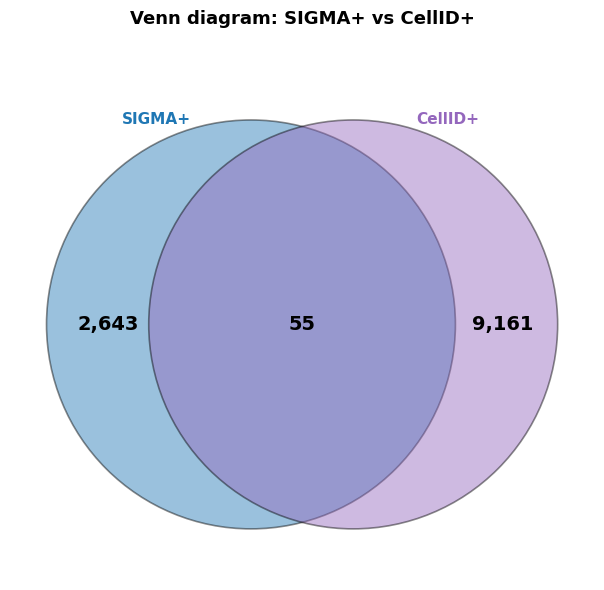

In [14]:
n_sigma  = int(mask_sigma.sum())
n_cellid = int(mask_cellid.sum())
n_both   = int((mask_sigma & mask_cellid).sum())

n_sigma_only  = n_sigma - n_both
n_cellid_only = n_cellid - n_both

fig, ax = plt.subplots(figsize=(7, 6))

c1 = plt.Circle((0.43, 0.5), 0.28, color=BLUE, alpha=0.45, ec="black", lw=1.2)
c2 = plt.Circle((0.57, 0.5), 0.28, color=PURPLE, alpha=0.45, ec="black", lw=1.2)
ax.add_patch(c1)
ax.add_patch(c2)

ax.text(0.235, 0.50, f"{n_sigma_only:,}", ha="center", va="center", fontsize=14, fontweight="bold")
ax.text(0.50, 0.50, f"{n_both:,}", ha="center", va="center", fontsize=14, fontweight="bold")
ax.text(0.775, 0.50, f"{n_cellid_only:,}", ha="center", va="center", fontsize=14, fontweight="bold")

ax.text(0.30, 0.78, "SIGMA+", ha="center", va="center", fontsize=11, fontweight="bold", color=BLUE)
ax.text(0.70, 0.78, "CellID+", ha="center", va="center", fontsize=11, fontweight="bold", color=PURPLE)

ax.set_title("Venn diagram: SIGMA+ vs CellID+", fontsize=13, fontweight="bold")
ax.set_xlim(0.1, 0.9)
ax.set_ylim(0.15, 0.9)
ax.set_aspect("equal")
ax.axis("off")

plt.tight_layout()
fig.savefig("figures/SUP3-A.pdf", bbox_inches="tight", dpi=500)
plt.show()

In [15]:
adata_norm = adata_full.copy()
sc.pp.normalize_total(adata_norm, target_sum=1e6)
sc.pp.log1p(adata_norm)

In [16]:
def get_expression(adata, mask, gene):
    """Retrieve log1p-CPM expression values for a given gene and mask."""
    if gene not in adata.var_names:
        return np.array([])
    idx = adata.var_names.get_loc(gene)
    expr = adata.X[mask, idx]
    if hasattr(expr, "toarray"):
        expr = expr.toarray().flatten()
    return np.array(expr).flatten()

def mean_panel(adata, mask, genes):
    """Compute the mean expression of a list of genes for a given mask."""
    genes_ok = [g for g in genes if g in adata.var_names]
    if not genes_ok:
        return np.zeros(int(mask.sum()))
    idx = [adata.var_names.get_loc(g) for g in genes_ok]
    expr = adata.X[mask][:, idx]
    if hasattr(expr, "toarray"):
        expr = expr.toarray()
    return np.mean(expr, axis=1)

def format_pvalue(pval):
    return f"{pval:.3e}"

def boxplot_panel(ax, v1, v2, title, rng, n_sample=1000):
    """Boxplot comparing two sets of expression values (v1 = SIGMA, v2 = CellID)."""
    for i, (vals, color) in enumerate([(v1, BLUE), (v2, PURPLE)], start=1):
        bp = ax.boxplot(
            [v1, v2][i - 1:i],
            positions=[i], patch_artist=True, widths=0.5,
            notch=False, showfliers=False,
            medianprops=dict(color="black", linewidth=2), zorder=3
        )
        bp["boxes"][0].set_facecolor(color)
        bp["boxes"][0].set_alpha(0.75)
        for w in bp["whiskers"]: w.set(linewidth=1.0, linestyle="--")
        for c in bp["caps"]:     c.set(linewidth=1.0)

        s   = rng.choice(len(vals), size=min(n_sample, len(vals)), replace=False)
        jit = rng.uniform(-0.12, 0.12, size=len(s))
        ax.scatter(i + jit, vals[s], color=color, alpha=0.3, s=6, zorder=2, linewidths=0)

    stat, pval = mannwhitneyu(v1, v2, alternative="two-sided")
    ax.set_title(title + f"\np = {format_pvalue(pval)}", fontsize=11, fontweight="bold")
    ax.set_xticks([1, 2])
    ax.set_xticklabels([f"SIGMA+\n(n={len(v1):,})", f"CellID+\n(n={len(v2):,})"], fontsize=9)
    ax.set_ylabel("log1p-CPM", fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    return pval

def plot_gene_panel(genes, suptitle, figname, rng, n_cols=4, n_sample=1000, fig_format="pdf"):
    """Plot expression levels for a list of genes, SIGMA+ vs CellID+."""
    genes_ok = [g for g in genes if g in adata_norm.var_names]
    n_rows   = int(np.ceil(len(genes_ok) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 4))
    axes = np.atleast_1d(axes).flatten()
    for idx, gene in enumerate(genes_ok):
        boxplot_panel(axes[idx],
                      get_expression(adata_norm, mask_sigma.values, gene),
                      get_expression(adata_norm, mask_cellid.values, gene),
                      gene, rng, n_sample)
    for idx in range(len(genes_ok), len(axes)):
        axes[idx].axis("off")
    fig.suptitle(suptitle, fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(f"{figname}.{fig_format}", bbox_inches="tight", dpi=500)
    plt.show()


# Figure C - T cell identity markers

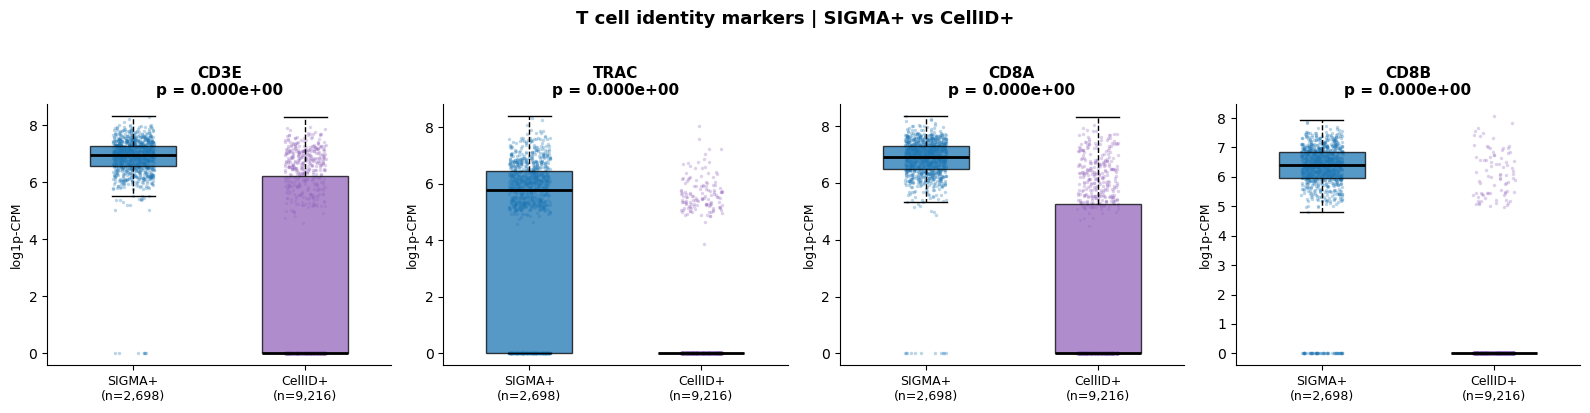

In [17]:
plot_gene_panel(
    T_CELL_MARKERS,
    "T cell identity markers | SIGMA+ vs CellID+",
    "figures/SUP3-C",
    rng
)

# Figure D - NK cell contamination markers

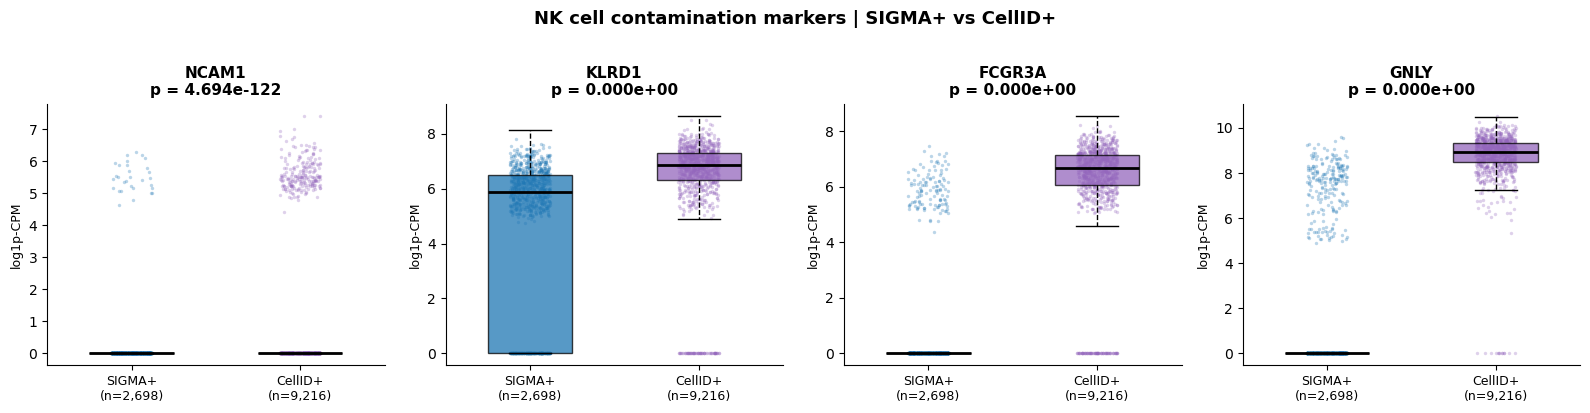

In [18]:
plot_gene_panel(
    NK_MARKERS,
    "NK cell contamination markers | SIGMA+ vs CellID+",
    "figures/SUP3-D",
    rng
)

# Figure E - Non-cytotoxic T cell markers

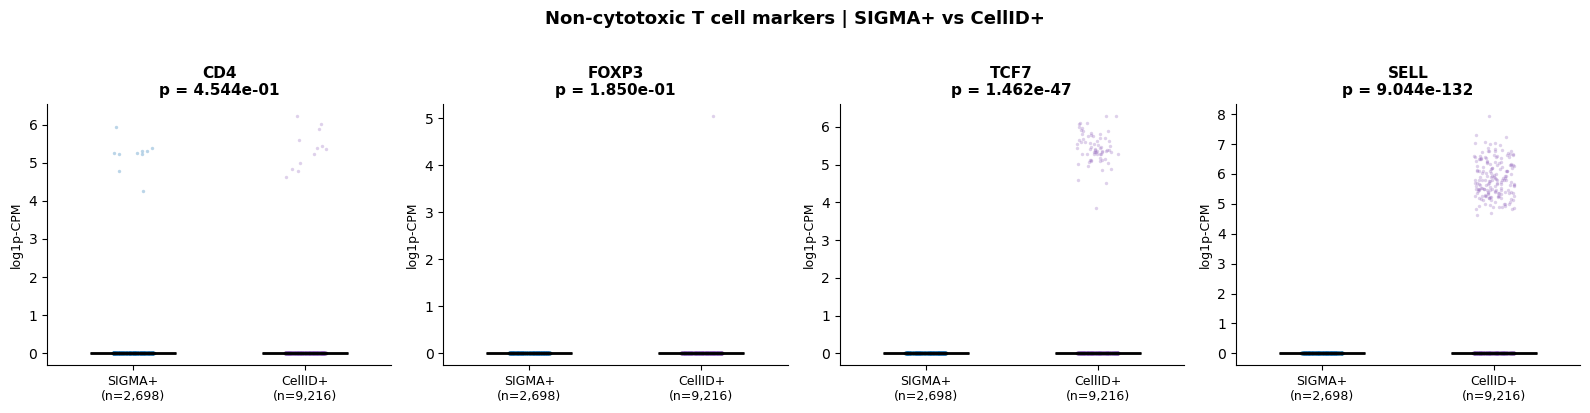

In [19]:
plot_gene_panel(
    NON_CYTOTOXIC,
    "Non-cytotoxic T cell markers | SIGMA+ vs CellID+",
    "figures/SUP3-E",
    rng
)

# Figure B - Summary panel scores

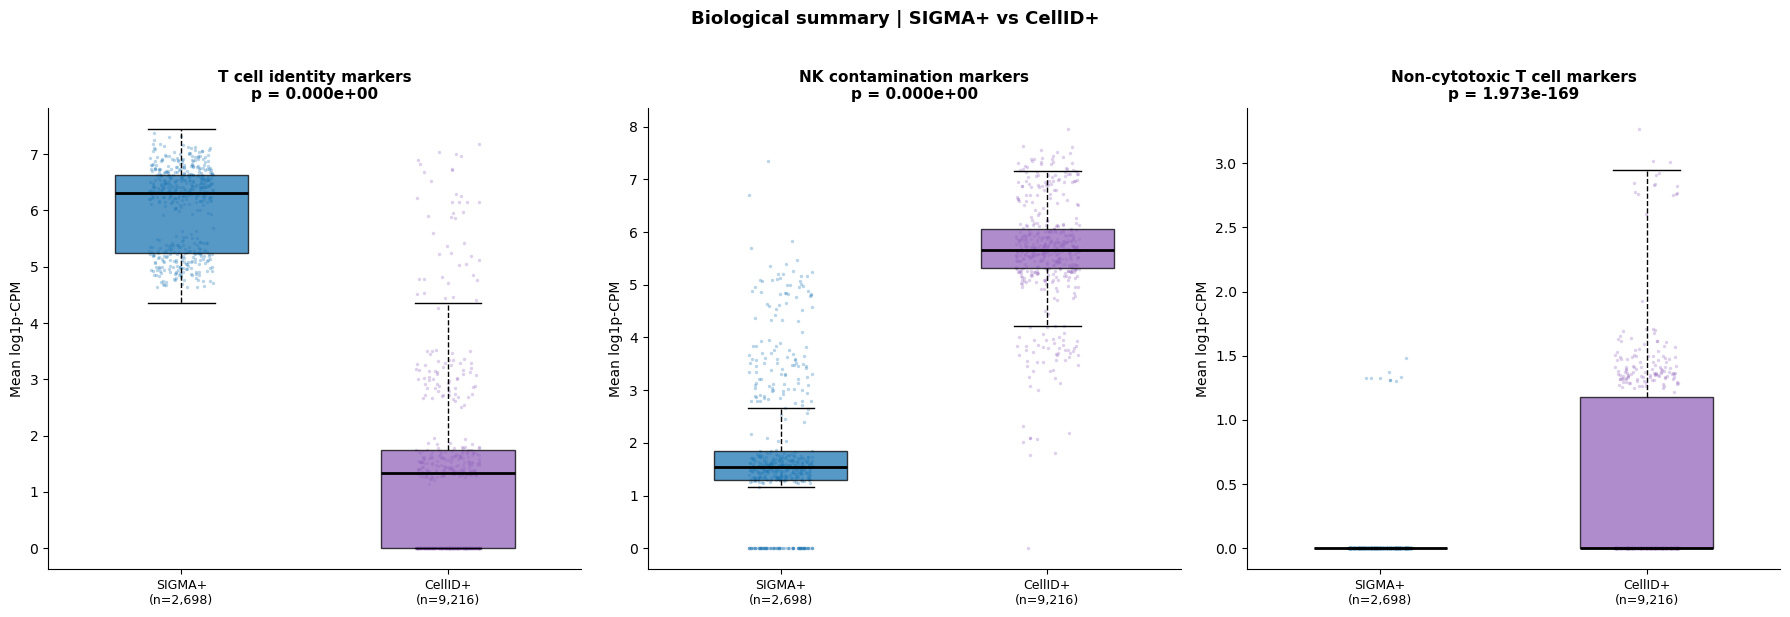

,Panel,SIGMA+ median,CellID+ median,p-value
0,T cell identity markers,6.312,1.330,0.000e+00
1,NK contamination markers,1.535,5.667,0.000e+00
2,Non-cytotoxic T cell markers,0.000,0.000,1.973e-169


In [20]:
panels = [
    (T_CELL_MARKERS, "T cell identity markers"),
    (NK_MARKERS, "NK contamination markers"),
    (NON_CYTOTOXIC,  "Non-cytotoxic T cell markers"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
rows = []

for ax, (genes, title) in zip(axes, panels):
    s = mean_panel(adata_norm, mask_sigma.values, genes)
    c = mean_panel(adata_norm, mask_cellid.values, genes)
    pval = boxplot_panel(ax, s, c, title, rng, n_sample=500)
    ax.set_ylabel("Mean log1p-CPM", fontsize=10)
    rows.append({"Panel": title,
                 "SIGMA+ median": round(float(np.median(s)), 3),
                 "CellID+ median": round(float(np.median(c)), 3),
                 "p-value": format_pvalue(pval)})

fig.suptitle("Biological summary | SIGMA+ vs CellID+", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
fig.savefig("figures/SUP3-B.pdf", bbox_inches="tight", dpi=500)
plt.show()

summary_df = pd.DataFrame(rows)
summary_df


# Final composite figure

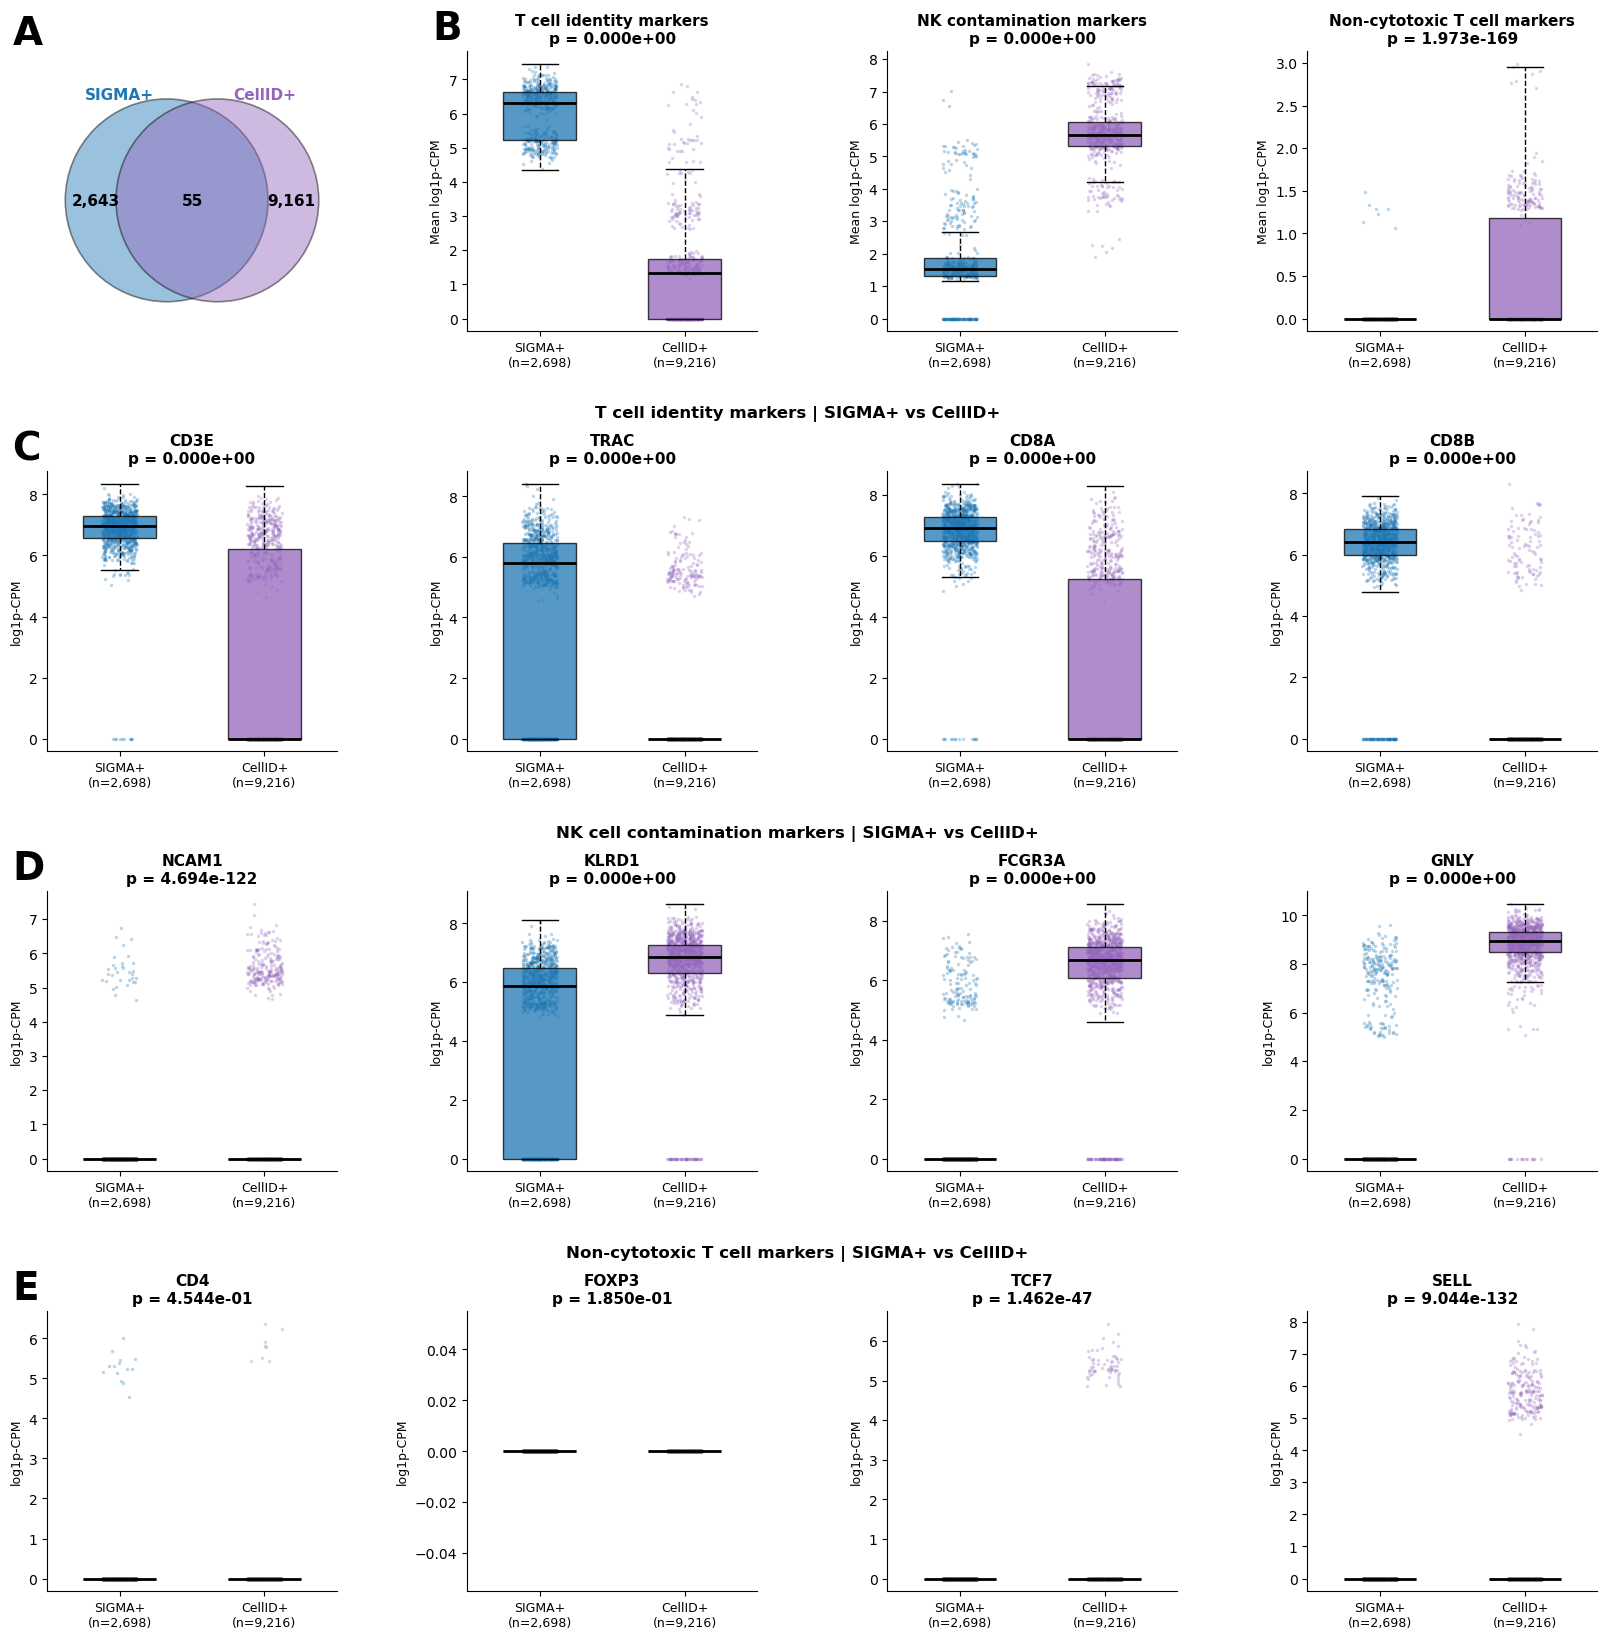

In [21]:
fig = plt.figure(figsize=(20, 20))
gs = gridspec.GridSpec(4, 4, figure=fig, hspace=0.5, wspace=0.45)

ax_venn = fig.add_subplot(gs[0, 0])
axB = [fig.add_subplot(gs[0, i]) for i in range(1, 4)]
axC = [fig.add_subplot(gs[1, i]) for i in range(4)]
axD = [fig.add_subplot(gs[2, i]) for i in range(4)]
axE = [fig.add_subplot(gs[3, i]) for i in range(4)]

# A
c1 = plt.Circle((0.43, 0.5), 0.28, color=BLUE, alpha=0.45, ec="black", lw=1.2)
c2 = plt.Circle((0.57, 0.5), 0.28, color=PURPLE, alpha=0.45, ec="black", lw=1.2)
ax_venn.add_patch(c1)
ax_venn.add_patch(c2)
ax_venn.text(0.235, 0.50, f"{n_sigma_only:,}", ha="center", va="center", fontsize=11, fontweight="bold")
ax_venn.text(0.50, 0.50, f"{n_both:,}", ha="center", va="center", fontsize=11, fontweight="bold")
ax_venn.text(0.775, 0.50, f"{n_cellid_only:,}", ha="center", va="center", fontsize=11, fontweight="bold")
ax_venn.text(0.30, 0.78, "SIGMA+", ha="center", fontsize=11, fontweight="bold", color=BLUE)
ax_venn.text(0.70, 0.78, "CellID+", ha="center", fontsize=11, fontweight="bold", color=PURPLE)
ax_venn.set_xlim(0.1, 0.9); ax_venn.set_ylim(0.15, 0.9)
ax_venn.set_aspect("equal"); ax_venn.axis("off")
ax_venn.text(-0.12, 1.15, "A", transform=ax_venn.transAxes, fontsize=28, fontweight="bold", va="top")

# B
panels_B = [
    (T_CELL_MARKERS, "T cell identity markers"),
    (NK_MARKERS, "NK contamination markers"),
    (NON_CYTOTOXIC,  "Non-cytotoxic T cell markers"),
]
for ax, (genes, title) in zip(axB, panels_B):
    s = mean_panel(adata_norm, mask_sigma.values, genes)
    c = mean_panel(adata_norm, mask_cellid.values, genes)
    boxplot_panel(ax, s, c, title, rng, n_sample=500)
    ax.set_ylabel("Mean log1p-CPM", fontsize=9)
axB[0].text(-0.12, 1.15, "B", transform=axB[0].transAxes, fontsize=28, fontweight="bold", va="top")

# C, D, E
for axrow, genes_list, letter, title in [
    (axC, T_CELL_MARKERS, "C", "T cell identity markers | SIGMA+ vs CellID+"),
    (axD, NK_MARKERS, "D", "NK cell contamination markers | SIGMA+ vs CellID+"),
    (axE, NON_CYTOTOXIC,  "E", "Non-cytotoxic T cell markers | SIGMA+ vs CellID+"),
]:
    genes_ok = [g for g in genes_list if g in adata_norm.var_names]
    for ax, gene in zip(axrow, genes_ok):
        boxplot_panel(ax,
                      get_expression(adata_norm, mask_sigma.values, gene),
                      get_expression(adata_norm, mask_cellid.values, gene),
                      gene, rng)
    for ax in axrow[len(genes_ok):]:
        ax.axis("off")
    axrow[0].text(-0.12, 1.15, letter, transform=axrow[0].transAxes,
                  fontsize=28, fontweight="bold", va="top")
    top = axrow[0].get_position().y1
    fig.text(0.5, top + 0.025, title, ha="center", va="bottom", fontsize=12, fontweight="bold")

fig.savefig("figures/SUP3-full.pdf", bbox_inches="tight", dpi=500)
plt.show()
